Between and Within: Income, Labour Markets, and Inter-State
Migration in India

**Author:** Rwiddhi Kundu  
**Original paper:** Internal Assessment, Urban Economics II,
University of Calcutta, 2022  
**Python implementation:** April 2026

This notebook implements the empirical analysis from the paper using
linearmodels (BetweenOLS and PanelOLS) with clustered standard errors.
See README for data sources and replication.

In [2]:
# all imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from linearmodels.panel import PanelOLS
from linearmodels import BetweenOLS

#### LOADING DATA

In [4]:
df = pd.read_excel('data/Migration_Data.xlsx', sheet_name='RAW_VALUES', header=0)
df.head()

,State,Year,Total_Population(Thousands),Urban Population(Thousands),Population Density,Labour Force Participation(Main+Marginal)*100/Population,NSDP_constant_prices,Social_Expenditure(Billions),Inter-State Migration,Per_capita_NSDP_constant_prices
0,Andaman and Nicobar Islands,1991,281,75,34,35.238597,6836.0,NaN,77923.0,22996.98
1,Andhra Pradesh,1991,66508,17887,242,45.052692,1434166.0,31.2,994141.0,21318.66
2,Arunachal Pradesh,1991,865,111,10,46.241201,26424.0,1.4,98653.0,30099.87
3,Assam,1991,22414,2488,286,36.088243,357661.0,11.1,487761.0,15734.25
4,Bihar,1991,64531,6712,685,32.158892,967308.0,30.7,1031566.0,11038.95


Calculated data file included in repository - see README for raw sources

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 10 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   State                                                     105 non-null    object 
 1   Year                                                      105 non-null    int64  
 2   Total_Population(Thousands)                               105 non-null    int64  
 3   Urban Population(Thousands)                               105 non-null    int64  
 4   Population Density                                        105 non-null    int64  
 5   Labour Force Participation(Main+Marginal)*100/Population  101 non-null    float64
 6   NSDP_constant_prices                                      90 non-null     float64
 7   Social_Expenditure(Billions)                              82 non-null     float64
 8   Inter-State Migratio

#### DATA CLEANING

In [7]:
# Drop Union Territories
ut_list = ["Andaman and Nicobar Islands", "Chandigarh", "Daman and Diu", "Dadra and Nagar Haveli", "Delhi", "Puducherry", "Lakshadweep"]
df = df[~df['State'].isin(ut_list)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 1 to 104
Data columns (total 10 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   State                                                     84 non-null     object 
 1   Year                                                      84 non-null     int64  
 2   Total_Population(Thousands)                               84 non-null     int64  
 3   Urban Population(Thousands)                               84 non-null     int64  
 4   Population Density                                        84 non-null     int64  
 5   Labour Force Participation(Main+Marginal)*100/Population  80 non-null     float64
 6   NSDP_constant_prices                                      79 non-null     float64
 7   Social_Expenditure(Billions)                              80 non-null     float64
 8   Inter-State Migration     

In [8]:
state_obs = df.groupby('State')['Year'].count()
states_to_keep = state_obs[state_obs >= 2].index
df = df[df['State'].isin(states_to_keep)]

print("States retained:", len(states_to_keep))

States retained: 28


In [9]:
print(df['State'].unique())

['Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir' 'Jharkhand'
 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur' 'Meghalaya'
 'Mizoram' 'Nagaland' 'Odisha' 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu'
 'Tripura' 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']


In [10]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df = df.rename(columns={'State': 'state','Year': 'year','Total_Population(Thousands)': 'pop_thousands',
                        'Urban_Population(Thousands)': 'urban_pop_thousands','Population_Density': 'density',
                        'Labour_Force_Participation(Main+Marginal)*100/Population': 'lfpr',
                        'Social_Expenditure(Billions)': 'social_exp','NSDP_constant_prices': 'nsdp',
                        'Per_capita_NSDP_constant_prices':'pc_nsdp', 'Inter-State_Migration': 'migration'})
df.head()

,state,year,pop_thousands,urban_pop_thousands,density,lfpr,nsdp,social_exp,migration,pc_nsdp
1,Andhra Pradesh,1991,66508,17887,242,45.052692,1434166.0,31.2,994141.0,21318.66
2,Arunachal Pradesh,1991,865,111,10,46.241201,26424.0,1.4,98653.0,30099.87
3,Assam,1991,22414,2488,286,36.088243,357661.0,11.1,487761.0,15734.25
4,Bihar,1991,64531,6712,685,32.158892,967308.0,30.7,1031566.0,11038.95
6,Chhattisgarh,1991,17615,3065,130,NaN,NaN,NaN,NaN,NaN


In [11]:
df.describe()

,year,pop_thousands,urban_pop_thousands,density,lfpr,nsdp,social_exp,migration,pc_nsdp
count,84.000000,84.000000,84.000000,84.000000,80.000000,7.900000e+01,80.00000,8.000000e+01,80.000000
mean,2001.000000,36165.857143,9972.226190,312.892857,40.532539,1.109717e+07,85.97125,1.301771e+06,45953.319750
std,8.214005,39374.526583,11671.139818,253.440852,5.350187,1.934978e+07,130.31709,1.565593e+06,36393.867165
min,1991.000000,406.000000,37.000000,10.000000,30.874660,1.442900e+04,0.70000,9.882000e+03,11038.950000
25%,1991.000000,2939.250000,595.750000,122.250000,36.639671,5.947915e+05,9.52500,1.360400e+05,22669.807500
50%,2001.000000,25448.000000,5727.000000,257.500000,41.650757,2.287287e+06,28.95000,8.573470e+05,36551.200000
75%,2011.000000,60371.000000,16237.250000,399.250000,43.982327,1.305518e+07,97.52500,1.906469e+06,53596.080000
max,2011.000000,199812.000000,50818.000000,1106.000000,52.574071,1.126595e+08,611.30000,9.087380e+06,259444.000000


#### Variable Construction

To ensure comparability across states and over time, the following transformations are applied:

##### Dependent Variable
- Migration rate = Migration / (Population*1000)
- Log transformation applied for skewness

##### Key Independent Variables
- LFPR: Converted from percentage to proportion(/100)
- Urbanization rate = Urban population / Total population
- Social expenditure share = (Social expenditure(billion) * / NSDP(lakh))* 10000
- Log population density

##### Rationale:
- Ratios remove scale effects across states
- Log transformations improve linearity and reduce skewness

In [12]:
df['log_pc_nsdp'] = np.log(df['pc_nsdp'] + 1e-6)
df['population'] = df['pop_thousands'] * 1000
df['urban_population'] = df['urban_pop_thousands'] * 1000
df['social_exp'] = df['social_exp'] * 1e9
df['nsdp'] = df['nsdp'] * 1e5

In [13]:
print(df['log_pc_nsdp'].describe())

count    80.000000
mean     10.530483
std       0.613018
min       9.309185
25%      10.028789
50%      10.506439
75%      10.889139
max      12.466296
Name: log_pc_nsdp, dtype: float64


In [14]:
df['migration_rate'] = df['migration'] / df['population']
df['log_migration_rate'] = np.log(df['migration_rate'] + 1e-6)

df['lfpr_rate'] = df['lfpr'] / 100
df['urbanization_rate'] = df['urban_population'] / df['population']
df['social_exp_share'] = df['social_exp'] / df['nsdp']
df['log_density'] = np.log(df['density'])

In [15]:
print(df['migration_rate'].describe())

count    80.000000
mean      0.048121
std       0.039573
min       0.006444
25%       0.018540
50%       0.036404
75%       0.059351
max       0.184845
Name: migration_rate, dtype: float64


In [16]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['log_migration_rate','lfpr_rate','urbanization_rate','social_exp_share','log_density','log_pc_nsdp'])

In [17]:
df.info()

print(len(df['state'].unique()))

<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, 1 to 104
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                77 non-null     object 
 1   year                 77 non-null     int64  
 2   pop_thousands        77 non-null     int64  
 3   urban_pop_thousands  77 non-null     int64  
 4   density              77 non-null     int64  
 5   lfpr                 77 non-null     float64
 6   nsdp                 77 non-null     float64
 7   social_exp           77 non-null     float64
 8   migration            77 non-null     float64
 9   pc_nsdp              77 non-null     float64
 10  log_pc_nsdp          77 non-null     float64
 11  population           77 non-null     int64  
 12  urban_population     77 non-null     int64  
 13  migration_rate       77 non-null     float64
 14  log_migration_rate   77 non-null     float64
 15  lfpr_rate            77 non-null     float64
 

#### Multicollinearity Check

In [19]:
# variation
print(df[['lfpr_rate','urbanization_rate','social_exp_share','log_density','log_pc_nsdp']].describe())

# Correlation
corr_matrix = df[['lfpr_rate','urbanization_rate','social_exp_share','log_density','log_pc_nsdp']].corr()
print(corr_matrix)

       lfpr_rate  urbanization_rate  social_exp_share  log_density  \
count  77.000000          77.000000         77.000000    77.000000   
mean    0.405868           0.267750          0.177909     5.414325   
std     0.052453           0.116902          0.147937     0.966688   
min     0.308747           0.086830          0.026557     2.302585   
25%     0.367711           0.185915          0.077643     4.812184   
50%     0.417913           0.259634          0.133531     5.552960   
75%     0.439814           0.339218          0.223957     6.025866   
max     0.525741           0.621659          0.726422     7.008505   

       log_pc_nsdp  
count    77.000000  
mean     10.547743  
std       0.616006  
min       9.309185  
25%      10.038524  
50%      10.514923  
75%      10.912637  
max      12.466296  
                   lfpr_rate  urbanization_rate  social_exp_share  \
lfpr_rate           1.000000           0.115351          0.035152   
urbanization_rate   0.115351           1.0

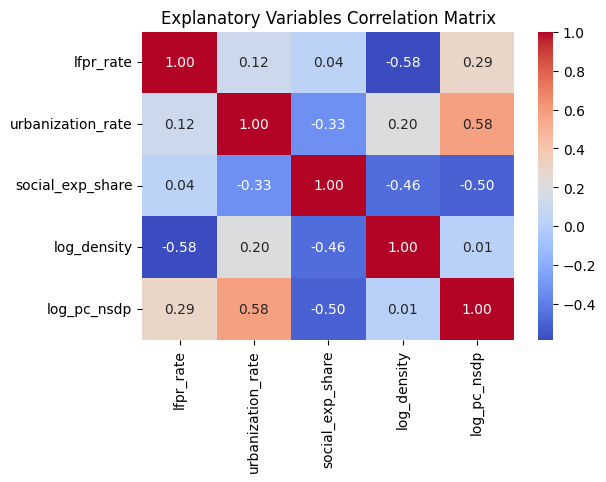

In [20]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Explanatory Variables Correlation Matrix")
plt.show()



*   Log NSDPpc and urbanization (0.58) indicate that income and urbanization capture overlapping dimensions of economic development across states, relevant for interpreting the between-state sequential results.
*   The negative correlation between social expenditure share and log NSDPpc (-0.50) reflects that poorer states tend to allocate a higher share of output to social spending.



In [21]:
X_check = df[['lfpr_rate','urbanization_rate','social_exp_share','log_density','log_pc_nsdp']].dropna()
X_check = sm.add_constant(X_check)

vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
vif["variable"] = X_check.columns

print(vif)

          VIF           variable
0  914.588060              const
1    1.816533          lfpr_rate
2    1.624315  urbanization_rate
3    1.923144   social_exp_share
4    2.327876        log_density
5    2.121885        log_pc_nsdp


All VIF values fall below conventional thresholds of 3 indicating that multicollinearity is not a mechanical concern in the within-state specification. The moderate correlation between income and urbanization (0.58) has substantive implications for the between-state analysis but does not inflate VIF values to problematic levels given their joint inclusion in the panel.

#### Panel Structure

The dataset is structured as a state-year panel:

- Entity dimension: State
- Time dimension: Year

This enables the use of fixed effects to control for:
- Time-invariant state characteristics
- Common time shocks

In [22]:
df = df.sort_values(['state', 'year'])
df = df.set_index(['state', 'year'])

####  Within-State Analysis (Fixed Effect)

In [23]:
y = df['log_migration_rate']

X = df[['lfpr_rate', 'urbanization_rate', 'social_exp_share', 'log_density','log_pc_nsdp']]
X = sm.add_constant(X)

model = PanelOLS(y,X,entity_effects=True,time_effects=True)
results = model.fit(cov_type='clustered', cluster_entity=True)
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     log_migration_rate   R-squared:                        0.2836
Estimator:                   PanelOLS   R-squared (Between):             -0.4690
No. Observations:                  77   R-squared (Within):              -0.0823
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.5325
Time:                        13:32:53   Log-likelihood                    54.455
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.3257
Entities:                          28   P-value                           0.0128
Avg Obs:                       2.7500   Distribution:                    F(5,42)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             5.0615
                            

#### Standardized Specification

To compare relative importance of regressors, variables are standardized (z-scores):

- Mean = 0  
- Standard deviation = 1  

This allows coefficient magnitudes to be interpreted on a common scale.

In [24]:
cols = ['lfpr_rate', 'urbanization_rate', 'social_exp_share', 'log_density','log_pc_nsdp']

for col in cols:
    df[col + '_z'] = (df[col] - df[col].mean()) / df[col].std()

In [25]:
y = df['log_migration_rate']
X_std = df[['lfpr_rate_z','urbanization_rate_z','social_exp_share_z','log_density_z','log_pc_nsdp']]
X_std = sm.add_constant(X_std)

model_std = PanelOLS(y,X_std,entity_effects=True,time_effects=True)
results_std = model_std.fit(cov_type='clustered', cluster_entity=True)

print(results_std.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     log_migration_rate   R-squared:                        0.2836
Estimator:                   PanelOLS   R-squared (Between):             -0.4690
No. Observations:                  77   R-squared (Within):              -0.0823
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.5325
Time:                        13:33:24   Log-likelihood                    54.455
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.3257
Entities:                          28   P-value                           0.0128
Avg Obs:                       2.7500   Distribution:                    F(5,42)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             5.0615
                            

#### Lagged Specification (Robustness)

Regressors are lagged by one Census period to address potential reverse causality.

Limitations:
- T = 3 reduces effective variation  
- Sample size falls to ~49 observations  
- Estimates rely on limited within-state differences  

Results are therefore interpreted cautiously.

In [28]:
df['lfpr_lag'] = df.groupby(level=0)['lfpr_rate'].shift(1)
df['urban_lag'] = df.groupby(level=0)['urbanization_rate'].shift(1)
df['social_lag'] = df.groupby(level=0)['social_exp_share'].shift(1)
df['density_lag'] = df.groupby(level=0)['log_density'].shift(1)
df['pc_nsdp_lag'] = df.groupby(level=0)['log_pc_nsdp'].shift(1)


df_lag = df.dropna()

y_lag = df_lag['log_migration_rate']

X_lag = df_lag[['lfpr_lag','urban_lag','social_lag','density_lag','pc_nsdp_lag']]
X_lag = sm.add_constant(X_lag)

model_lag = PanelOLS(
    y_lag,
    X_lag,
    entity_effects=True,
    time_effects=True
)

results_lag = model_lag.fit(cov_type='clustered', cluster_entity=True)

print(results_lag.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     log_migration_rate   R-squared:                        0.2753
Estimator:                   PanelOLS   R-squared (Between):             -0.4909
No. Observations:                  49   R-squared (Within):              -0.5121
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.6100
Time:                        13:44:35   Log-likelihood                    43.754
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.2153
Entities:                          27   P-value                           0.3466
Avg Obs:                       1.8148   Distribution:                    F(5,16)
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             0.3001
                            

#### Between-State Estimator

In [26]:

be_model = BetweenOLS(df['log_migration_rate'],
                      df[['lfpr_rate','urbanization_rate',
                                'social_exp_share','log_density','log_pc_nsdp']])
be_results = be_model.fit()
print(be_results.summary)



                         BetweenOLS Estimation Summary                          
Dep. Variable:     log_migration_rate   R-squared:                        0.9637
Estimator:                 BetweenOLS   R-squared (Between):              0.9637
No. Observations:                  28   R-squared (Within):              -11.091
Date:                Sun, Apr 12 2026   R-squared (Overall):              0.9421
Time:                        13:34:42   Log-likelihood                   -27.596
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      122.06
Entities:                          28   P-value                           0.0000
Avg Obs:                       2.7500   Distribution:                    F(5,23)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             122.06
                            

Sequential Specifications

1. BE(1): Income Only
2. BE(2): Income + Urbanization
3. BE(3): + Population Density
4. BE(3b): 3 + LFPR
5. BE(3c): 3 + Social Expenditure
6. BE(4): Full Specification

In [29]:
# Model 1: Income (only)
X1 = df[['log_pc_nsdp']]
X1 = sm.add_constant(X1)

be_model1 = BetweenOLS(df['log_migration_rate'], X1)
be_results1 = be_model1.fit()
print("=== MODEL 1: Income ===")
print(be_results1)

=== MODEL 1: Income ===
                         BetweenOLS Estimation Summary                          
Dep. Variable:     log_migration_rate   R-squared:                        0.5303
Estimator:                 BetweenOLS   R-squared (Between):              0.5303
No. Observations:                  28   R-squared (Within):              -15.293
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.0916
Time:                        13:50:17   Log-likelihood                   -22.170
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      29.359
Entities:                          28   P-value                           0.0000
Avg Obs:                       2.7500   Distribution:                    F(1,26)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             29.359
    

In [30]:
# Model 2: income + urbanization
X2 = df[['log_pc_nsdp', 'urbanization_rate']]
X2 = sm.add_constant(X2)

be_model2 = BetweenOLS(df['log_migration_rate'], X2)
be_results2 = be_model2.fit()
print("=== MODEL 2: Income + Urbanization ===")
print(be_results2)

=== MODEL 2: Income + Urbanization ===
                         BetweenOLS Estimation Summary                          
Dep. Variable:     log_migration_rate   R-squared:                        0.5906
Estimator:                 BetweenOLS   R-squared (Between):              0.5906
No. Observations:                  28   R-squared (Within):              -21.183
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.2639
Time:                        13:50:28   Log-likelihood                   -20.246
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      18.035
Entities:                          28   P-value                           0.0000
Avg Obs:                       2.7500   Distribution:                    F(2,25)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):         

In [31]:
# Model 3: income + urbanization + Density
X3 = df[['log_pc_nsdp', 'urbanization_rate', 'log_density']]
X3 = sm.add_constant(X3)

be_model3 = BetweenOLS(df['log_migration_rate'], X3)
be_results3 = be_model3.fit()
print("=== MODEL 3: Income + Urbanization + Density ===")
print(be_results3)

=== MODEL 3: Income + Urbanization + Density ===
                         BetweenOLS Estimation Summary                          
Dep. Variable:     log_migration_rate   R-squared:                        0.5986
Estimator:                 BetweenOLS   R-squared (Between):              0.5986
No. Observations:                  28   R-squared (Within):              -19.434
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.1834
Time:                        13:50:32   Log-likelihood                   -19.973
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      11.928
Entities:                          28   P-value                           0.0001
Avg Obs:                       2.7500   Distribution:                    F(3,24)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust)

In [32]:
# Model 3b: income + urbanization + Density + LFPR
X3b = df[['log_pc_nsdp', 'urbanization_rate', 'log_density', 'lfpr_rate']]
X3b = sm.add_constant(X3b)
be_model3b = BetweenOLS(df['log_migration_rate'], X3b).fit()
print("=== MODEL 3b: + LFPR ===")
print(be_model3b)

=== MODEL 3b: + LFPR ===
                         BetweenOLS Estimation Summary                          
Dep. Variable:     log_migration_rate   R-squared:                        0.5992
Estimator:                 BetweenOLS   R-squared (Between):              0.5992
No. Observations:                  28   R-squared (Within):              -19.096
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.1674
Time:                        13:51:28   Log-likelihood                   -19.950
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      8.5970
Entities:                          28   P-value                           0.0002
Avg Obs:                       2.7500   Distribution:                    F(4,23)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             8.5970
   

In [33]:
# Model 3c: income + urbanization + density + social exp (without LFPR)
X3c = df[['log_pc_nsdp', 'urbanization_rate', 'log_density', 'social_exp_share']]
X3c = sm.add_constant(X3c)
be_model3c = BetweenOLS(df['log_migration_rate'], X3c).fit()
print("=== MODEL 3c: + Social Exp ===")
print(be_model3c)

=== MODEL 3c: + Social Exp ===
                         BetweenOLS Estimation Summary                          
Dep. Variable:     log_migration_rate   R-squared:                        0.6207
Estimator:                 BetweenOLS   R-squared (Between):              0.6207
No. Observations:                  28   R-squared (Within):              -25.457
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.3949
Time:                        13:51:43   Log-likelihood                   -19.177
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      9.4107
Entities:                          28   P-value                           0.0001
Avg Obs:                       2.7500   Distribution:                    F(4,23)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             9.41

In [34]:
# Model 4: All variables
X4 = df[['log_pc_nsdp', 'urbanization_rate', 'log_density', 'lfpr_rate', 'social_exp_share']]
X4 = sm.add_constant(X4)

be_model4 = BetweenOLS(df['log_migration_rate'], X4)
be_results4 = be_model4.fit()

print("=== MODEL 4: Full Specification ===")
print(be_results4)

=== MODEL 4: Full Specification ===
                         BetweenOLS Estimation Summary                          
Dep. Variable:     log_migration_rate   R-squared:                        0.6215
Estimator:                 BetweenOLS   R-squared (Between):              0.6215
No. Observations:                  28   R-squared (Within):              -25.018
Date:                Sun, Apr 12 2026   R-squared (Overall):             -0.3745
Time:                        13:52:23   Log-likelihood                   -19.148
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      7.2257
Entities:                          28   P-value                           0.0004
Avg Obs:                       2.7500   Distribution:                    F(5,22)
Min Obs:                       1.0000                                           
Max Obs:                       3.0000   F-statistic (robust):            